In [41]:
!pip install numpy scipy scikit-learn matplotlib

In [42]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import cholesky, solve_triangular
from scipy.special import expit

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

Load Dataset

In [43]:
# Load Breast Cancer dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Convert labels (malignant =1 , benign =0)
y = 1 - y

# Train test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# To make GP faster we take subset
X_train = X_train_full[:150]
y_train = y_train_full[:150]

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (150, 30)
Test size: (114, 30)


In [44]:
# sigmoid function
def sigmoid(f):
    return expit(f)

# likelihood derivatives
def likelihood_derivatives(y, f):

    pi = sigmoid(f)       # probability
    grad = y - pi         # gradient
    W = pi * (1 - pi)     # second derivative

    return W, grad, pi

Implement RBF Kernel

In [45]:
def rbf_kernel(X1, X2, length_scale=2.0, signal_var=1.0):

    diff = X1[:,None,:] - X2[None,:,:]
    sqdist = np.sum(diff**2, axis=2)

    K = signal_var * np.exp(-0.5 * sqdist / length_scale**2)

    return K

# 3.1 Algo

Implementation of 3.1 algo

In [46]:
def algorithm_3_1_gp_laplace(X_train, y_train,
                             length_scale=2.0,
                             signal_var=1.0,
                             max_iter=50,
                             tol=1e-6):

    n = len(y_train)

    # kernel matrix
    K = rbf_kernel(X_train, X_train, length_scale, signal_var)
    K += 1e-6*np.eye(n)

    # initialize latent function
    f = np.zeros(n)

    convergence = []

    for i in range(max_iter):

        W, grad, pi = likelihood_derivatives(y_train, f)

        W_sqrt = np.sqrt(W)

        B = np.eye(n) + (W_sqrt[:,None]*K)*W_sqrt[None,:]

        L = cholesky(B, lower=True)

        b = W*f + grad

        tmp1 = W_sqrt*(K@b)
        tmp2 = solve_triangular(L,tmp1,lower=True)
        tmp3 = solve_triangular(L.T,tmp2,lower=False)

        a = b - W_sqrt*tmp3

        f_new = K@a

        delta = np.linalg.norm(f_new-f)
        convergence.append(delta)

        if delta < tol:
            f = f_new
            break

        f = f_new

    W_hat,_,pi_hat = likelihood_derivatives(y_train,f)

    return f,K,L,a,W_hat,pi_hat,convergence

In [47]:
f_hat, K, L, a, W_hat, pi_hat, conv = algorithm_3_1_gp_laplace(
    X_train, y_train
)

print("Algorithm 3.1 completed")
print("Iterations:", len(conv))

Algorithm 3.1 completed
Iterations: 5



Newton Convergence

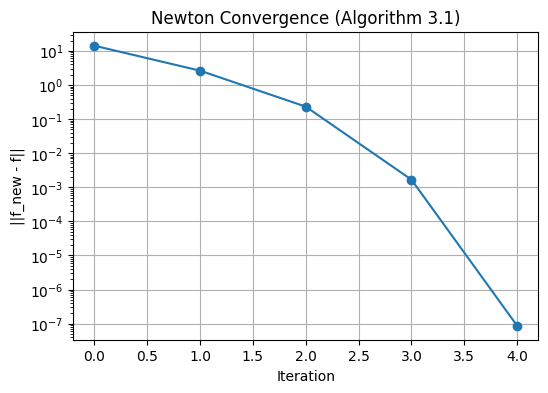

In [48]:
plt.figure(figsize=(6,4))

plt.semilogy(conv, marker='o')
plt.xlabel("Iteration")
plt.ylabel("||f_new - f||")
plt.title("Newton Convergence (Algorithm 3.1)")
plt.grid()

plt.show()

Latent f_hat

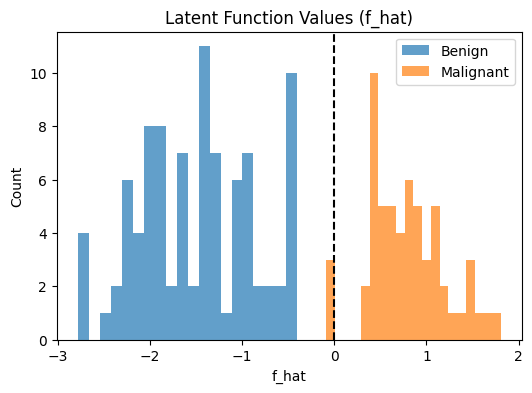

In [49]:
plt.figure(figsize=(6,4))

plt.hist(f_hat[y_train==0], bins=20, alpha=0.7,label="Benign")
plt.hist(f_hat[y_train==1], bins=20, alpha=0.7,label="Malignant")

plt.axvline(0,color="black",linestyle="--")

plt.title("Latent Function Values (f_hat)")
plt.xlabel("f_hat")
plt.ylabel("Count")
plt.legend()

plt.show()

Kernel Matrix

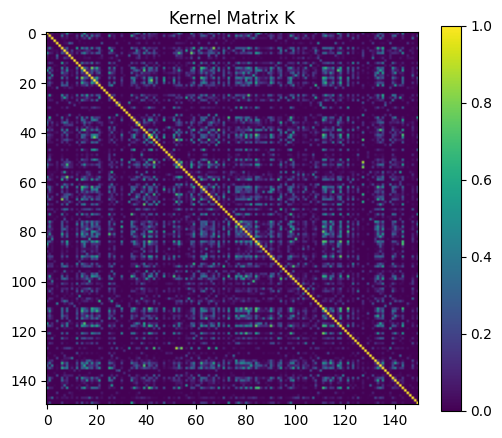

In [50]:
plt.figure(figsize=(6,5))

plt.imshow(K,cmap="viridis")
plt.colorbar()

plt.title("Kernel Matrix K")

plt.show()

# 3.2 Algo

Implementation of 3.2 algo

In [51]:
def algorithm_3_2_predict(X_train,X_test,a,L,W_hat,
                          length_scale=2.0,
                          signal_var=1.0,
                          n_samples=2000):

    K_star = rbf_kernel(X_test,X_train,length_scale,signal_var)

    K_starstar = np.diag(
        rbf_kernel(X_test,X_test,length_scale,signal_var)
    )

    mu_star = K_star@a

    W_sqrt = np.sqrt(W_hat)

    v = solve_triangular(
        L,(W_sqrt[None,:]*K_star).T,lower=True
    )

    var_star = K_starstar - np.sum(v**2,axis=0)
    var_star = np.maximum(var_star,1e-10)

    f_samples = np.random.normal(
        mu_star[:,None],
        np.sqrt(var_star)[:,None],
        size=(len(mu_star),n_samples)
    )

    prob = sigmoid(f_samples).mean(axis=1)

    return mu_star,var_star,prob

In [52]:
mu_test,var_test,prob_test = algorithm_3_2_predict(
    X_train,X_test,a,L,W_hat
)

print("Algorithm 3.2 completed")

Algorithm 3.2 completed


Prediction Accuracy

In [53]:
from sklearn.metrics import accuracy_score
y_pred = (prob_test>0.5).astype(int)
acc = accuracy_score(y_test,y_pred)

print("Test Accuracy:",acc)

Test Accuracy: 0.9473684210526315


Predictive Probability

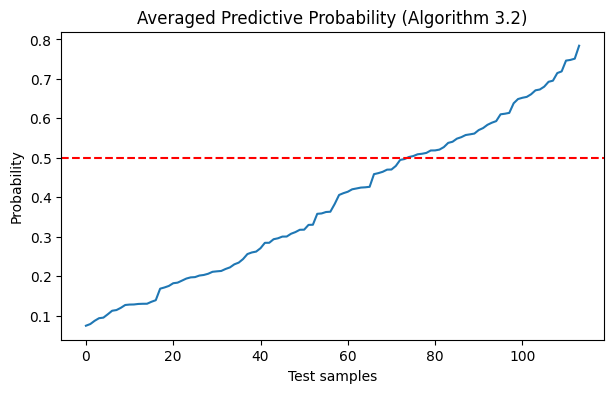

In [54]:
idx = np.argsort(prob_test)
plt.figure(figsize=(7,4))

plt.plot(prob_test[idx])
plt.axhline(0.5,color="red",linestyle="--")

plt.xlabel("Test samples")
plt.ylabel("Probability")
plt.title("Averaged Predictive Probability (Algorithm 3.2)")

plt.show()

Predictive Uncertainty

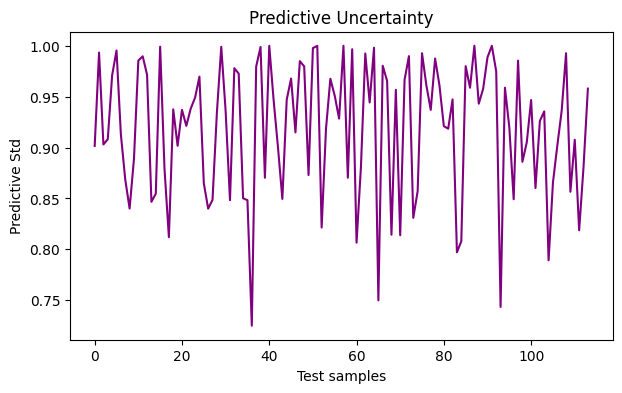

In [55]:
std_test = np.sqrt(var_test)

plt.figure(figsize=(7,4))

plt.plot(std_test,color="purple")

plt.xlabel("Test samples")
plt.ylabel("Predictive Std")
plt.title("Predictive Uncertainty")

plt.show()

ROC Curve

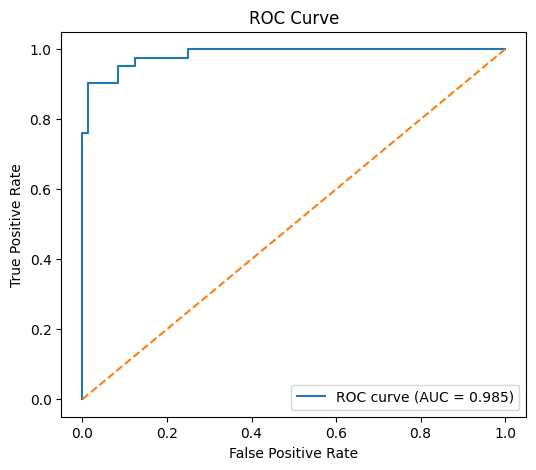

In [56]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, prob_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="ROC curve (AUC = %0.3f)" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

Predictive Std Distribution

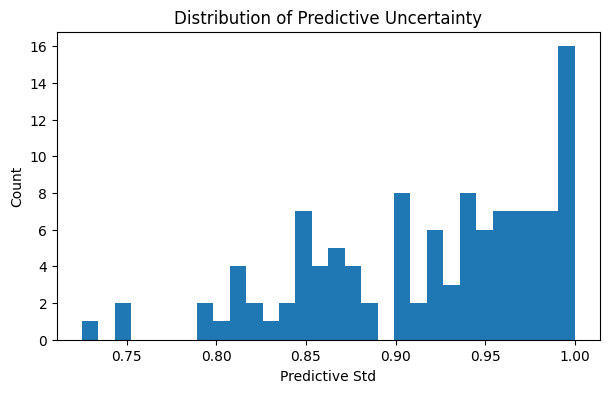

In [57]:
plt.figure(figsize=(7,4))

plt.hist(std_test, bins=30)

plt.xlabel("Predictive Std")
plt.ylabel("Count")
plt.title("Distribution of Predictive Uncertainty")

plt.show()